In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#1. Dataset
[Tải dataset tại đây!](http://bias.csr.unibo.it/fvc2002/download.asp)

In [ ]:
# !unzip /content/drive/MyDrive/DB1_B.zip -d /content/drive/MyDrive/fvc_dataset/

In [ ]:
num_fingerprint = len(os.listdir('/content/drive/MyDrive/fvc_dataset/'))
print("So luong van tay: ", num_fingerprint)

So luong van tay:  80


In [ ]:
import cv2
import math
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [ ]:
folder = '/content/drive/MyDrive/fvc_dataset/'
paths = os.listdir(folder)
img_paths =[]
for path in paths:
  full_path = os.path.join(folder,path)
  img_paths.append(full_path)

In [ ]:
def normalise(img):
    return (img - np.mean(img)) / (np.std(img))

def process_img(img_path):
  img = cv2.imread(img_path)
  gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

  # làm mượt
  blur = cv2.GaussianBlur(gray,(9,9),0)

  # threshold
  thresh = cv2.adaptiveThreshold(
      blur,255,
      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
      cv2.THRESH_BINARY_INV,
      15,2
  )

  # morphology closing
  kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15))
  mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

  # tìm contour
  contours,_ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

  # contour lớn nhất
  max_contour = max(contours, key=cv2.contourArea)

  # bounding box
  x,y,w,h = cv2.boundingRect(max_contour)

  mask = mask[y:y+h,x:x+w]
  roi = gray[y:y+h,x:x+w]
  norm_img = normalise(roi)
  return mask ,roi, norm_img

#2. Pipline
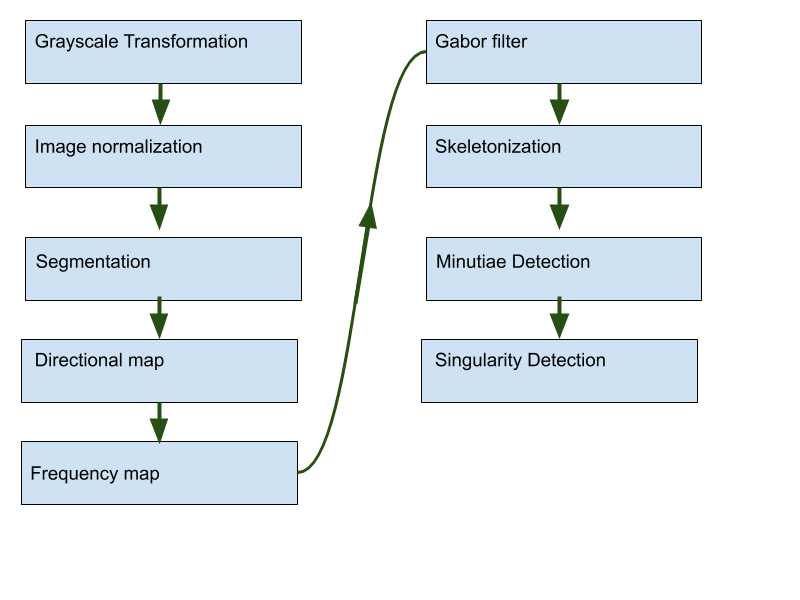

In [ ]:
def normalize_pixel(value, mean, variance, m0, v0):
  x = np.sqrt(v0 * (value - mean)**2 / variance)
  if value < mean:
    return m0 -x
  else:
    return m0 + x
def normalize(img, m0 =100 , v0=100):
  m = np.mean(img)
  v = np.var(img)
  (w,h) = img.shape
  normalize_img = img.copy()
  for i in range(w):
    for j in range(h):
      normalize_img[i,j] = normalize_pixel(img[i,j], m, v, m0, v0)
  return normalize_img

###Công thức tính góc:
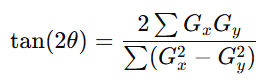

In [ ]:
# directional map
def calc_angles(im, w, smoth = False):
  # w: kich thuoc cua block
  j1 = lambda x,y: 2*x*y
  j2 = lambda x,y:  x**2 -y**2
  j3 = lambda x,y: x**2+ y**2
  (y, x) = im.shape

  sobelOperator = [[-1, 0, 1], [-2, 0,2],[-1,0,1]]
  ySobel = np.array(sobelOperator).astype(np.int32)
  xSobel = np.transpose(ySobel).astype(np.int32)

  result = [[] for i in range(1,y,w)]

  Gx_ = cv2.filter2D(im/125, -1, ySobel) *125
  Gy_ = cv2.filter2D(im/125, -1, xSobel)  *125

  for j in range(1,y,w):
    for i in range(1,x,w):
      nominator = 0
      denominator =0
      # Tinh tung goc pixel
      for l in range(j, min(j+w,y-1)):
        for k in range(i, min(i+w,x-1)):
          Gx = round(Gx_[l,k])
          Gy = round(Gy_[l,k])
          nominator += j1(Gx,Gy)
          denominator += j2(Gx,Gy)
      if nominator or denominator:
        angle = (math.pi + math.atan2(nominator,denominator)) /2
        result[int((j-1)//w)].append(angle)
      else:
        result[int((j-1)//w)].append(0)
  result = np.array(result)
  if smoth:
    result = smooth_angles(result)
  return result

def gauss(x,y):
  sigma = 1.0
  return (1/(2 * np.pi *sigma)) * (np.exp(-(x**2 + y**2)/(2* sigma**2)))

# kernel(i,j) = gauss(x,y)
def kernel_from_function(size,f):
  kernel = [[] for i in range(0,size)]
  for i in range(0,size):
    for j in range(0,size):
      kernel[i].append(f(i-size/2, j-size/2))
  return kernel

def smooth_angles(angles):
  angles = np.array(angles)
  # bien goc thanh vector
  cos = np.cos(angles.copy() *2)
  sin = np.sin(angles.copy() *2)

  kernel = np.array(kernel_from_function(5, gauss))

  cos_angles = cv2.filter2D(cos/125, -1, kernel) *125
  sin_angles = cv2.filter2D(sin/125, -1, kernel)  *125
  smooth_angles = np.arctan2(sin_angles, cos_angles) /2
  return smooth_angles

def get_line_ends(i,j,w,tang):
  if tang >=-1 and tang <=1 :
    # do pt duong thang nay di qua tam block
    begin =(i, int(-w/2*tang +j +w/2))
    end = (i+w, int(w/2*tang +j +w/2))
  else:
    begin= (int(i+w/2 + w/(2*tang)), j+w//2)
    end = (int(i+w/2 - w/(2*tang)), j-w//2)
  return begin, end

def visualize_angles(im, mask, angles, w):
  (y,x) = im.shape
  result = cv2.cvtColor(np.zeros(im.shape,np.uint8), cv2.COLOR_GRAY2BGR)
  mask_threshold = (w - 1) ** 2
  for i in range(1, x, w):
      for j in range(1, y, w):
        radian = np.sum(mask[j - 1 : j + w, i - 1 : i + w])
        if radian > mask_threshold:
          tang = math.tan(angles[(j - 1) // w][(i - 1) // w])
          (begin, end) = get_line_ends(i, j, w, tang)
          cv2.line(result, begin, end, (0,255,0),1)

  result = cv2.resize(result,(x,y))
  return result

In [ ]:
# frequency map
def frequest(img, orientim, kernel_size, minLength, maxLength):
  rows,cols = img.shape
  cos = np.cos(orientim *2)
  sin = np.sin(orientim *2)
  block_orient = math.atan2(sin, cos) /2

  img_rotate = nd.rotate(
      img,
      block_orient/np.pi * 180 +90,
      axes=(1,0),
      reshape = False,
      order =0,
      mode='nearest'
  )
  crop_size = int(np.fix(rows/np.sqrt(2)))
  offset = int(np.fix((rows - crop_size) /2))

  # vung anh nho sau khi da xoay
  img_crop = img_rotate[offset:offset+crop_size,offset:offset+crop_size]
  ridge_sum = np.sum(img_crop, axis=0) #chuyen ve 1D

  dilation = nd.grey_dilation(
      ridge_sum,
      kernel_size,
      structure=np.ones(kernel_size)
  )
  ridge_noise = np.abs(ridge_sum - dilation)
  peak_thresh = 2
  peak_max_idx = np.where((ridge_noise < peak_thresh) & (ridge_sum > np.mean(ridge_sum)))
  _, no_of_peak = np.shape(peak_max_idx)

  if no_of_peak <2:
    freq_block = np.zeros(img.shape)
  else:
    length = (peak_max_idx[0][-1] - peak_max_idx[0][0]) /(no_of_peak -1)
    if length >= minLength and length <= maxLength:
      freq_block = 1/np.double(length) *np.ones(img.shape)
    else:
      freq_block = np.zeros(img.shape)
  return freq_block

def ridge_freq(img, mask, orient, block_size, kernel_size,minLength, maxLength):
  rows, cols = img.shape
  freq = np.zeros((rows, cols))

  for row in range(0, rows - block_size, block_size):
    for col in range(0,cols - block_size, block_size):
      image_block = img[row: row+ block_size, col: col+block_size]
      angle_block = orient[row//block_size][col // block_size]
      if angle_block :
        freq[row: row+ block_size, col: col+block_size] = frequest(
            image_block,
            angle_block,
            kernel_size,
            minLength,
            maxLength
        )
  freq = freq * mask
  freq_1D = np.reshape(freq,(1,rows*cols))
  idx = np.where(freq_1D >0)
  idx = np.array(idx)
  idx = idx[1,:]
  non_zero_in_freq = freq_1D[0][idx]
  medianfreq = np.median(non_zero_in_freq) * mask

  return medianfreq


In [ ]:
# Gabor Filter
def gabor_filter(img, orient, freq, kx=0.65, ky =0.65):
  step = 3
  img = np.double(img)
  rows , cols = img.shape
  return_img = np.zeros((rows, cols))
  freq_1d =  freq.flatten()
  freq_idx = np.array(np.where(freq_1d > 0))
  non_zero_freq = freq_1d[freq_idx]
  non_zero_freq = np.double(np.round(non_zero_freq*100))/100
  unique_freq = np.unique(non_zero_freq)

  sigma_x = 1/unique_freq *kx
  sigma_y = 1/unique_freq *ky
  block_size = int(np.round(3*np.max([sigma_x, sigma_y])))
  array = np.linspace(-block_size, block_size, 2*block_size+1)
  x,y = np.meshgrid(array,array)

  reffilter = np.exp(
        -(
            (
                (np.power(x, 2)) / (sigma_x * sigma_x)
                + (np.power(y, 2)) / (sigma_y * sigma_y)
            )
        )
  ) * np.cos(2 * np.pi * unique_freq[0] * x)
  filt_rows, filt_cols = reffilter.shape
  gabor_filter = np.array(np.zeros((180 // step, filt_rows, filt_cols)))

  for degree in range(0, 180 // step):
      rot_filt = nd.rotate(
          reffilter, -(degree * step + 90), reshape=False
      )
      gabor_filter[degree] = rot_filt

  maxorient_index = np.round(180 / step)
  orient_index = np.round(orient / np.pi * 180 / step)
  for i in range(0, rows // 16):
      for j in range(0, cols // 16):
          if orient_index[i][j] < 1:
              orient_index[i][j] = orient_index[i][j] + maxorient_index
          if orient_index[i][j] > maxorient_index:
              orient_index[i][j] = orient_index[i][j] - maxorient_index

  block_size = int(block_size)
  valid_row, valid_col = np.where(freq > 0)
  final_idx = np.where(
      (valid_row > block_size)
      & (valid_row < rows - block_size)
      & (valid_col > block_size)
      & (valid_col < cols - block_size)
  )

  for k in range(0, np.shape(final_idx)[1]):
      r = valid_row[final_idx[0][k]]
      c = valid_col[final_idx[0][k]]
      img_block = img[r - block_size : r + block_size + 1,
        c - block_size : c + block_size + 1
      ]
      return_img[r][c] = np.sum(
          img_block * gabor_filter[int(orient_index[r // 16][c // 16]) - 1]
      )

  gabor_img = 255 - np.array((return_img < 0) * 255).astype(np.uint8)

  return gabor_img

In [ ]:
def minutiae_at(pixels, i, j, kernel_size):

    if pixels[i][j] == 1:
        if kernel_size == 3:
            cells = [
                (-1, -1),
                (-1, 0),
                (-1, 1),
                (0, 1),
                (1, 1),
                (1, 0),
                (1, -1),
                (0, -1),
                (-1, -1),
            ]
        else:
            cells = [
                (-2, -2),
                (-2, -1),
                (-2, 0),
                (-2, 1),
                (-2, 2),
                (-1, 2),
                (0, 2),
                (1, 2),
                (2, 2),
                (2, 1),
                (2, 0),
                (2, -1),
                (2, -2),
                (1, -2),
                (0, -2),
                (-1, -2),
                (-2, -2),
            ]

        values = [pixels[i + l][j + k] for k, l in cells]

        crossings = 0
        for k in range(0, len(values) - 1):
            crossings += abs(values[k] - values[k + 1])
        crossings //= 2

        if crossings == 1:
            return "ending"
        if crossings == 3:
            return "bifurcation"

    return "none"


def calculate_minutiaes(im, kernel_size=3):
    biniry_image = np.zeros_like(im)
    biniry_image[im < 10] = 1.0
    biniry_image = biniry_image.astype(np.int8)

    (y, x) = im.shape
    result = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB)
    colors = {"ending": (150, 0, 0), "bifurcation": (0, 150, 0)}

    for i in range(1, x - kernel_size // 2):
        for j in range(1, y - kernel_size // 2):
            minutiae = minutiae_at(biniry_image, j, i, kernel_size)
            if minutiae != "none":
                cv2.circle(result, (i, j), radius=2, color=colors[minutiae], thickness=2)

    return result

In [ ]:
from skimage.morphology import skeletonize as skelt
from skimage.morphology import thin

def skeletonize(image_input):
    image = np.zeros_like(image_input)
    image[image_input == 0] = 1.0
    output = np.zeros_like(image_input)
    skeleton = skelt(image)
    output[skeleton] = 255
    cv2.bitwise_not(output, output)
    return output


def thinning_morph(image, kernel):
    thining_image = np.zeros_like(image)
    img = image.copy()

    while 1:
        erosion = cv2.erode(img, kernel, iterations=1)
        dilatate = cv2.dilate(erosion, kernel, iterations=1)

        subs_img = np.subtract(img, dilatate)
        cv2.bitwise_or(thining_image, subs_img, thining_image)
        img = erosion.copy()

        done = np.sum(img) == 0

        if done:
            break

    down = np.zeros_like(thining_image)
    down[1:-1, :] = thining_image[0:-2,]
    down_mask = np.subtract(down, thining_image)
    down_mask[0:-2, :] = down_mask[1:-1,]
    cv2.imshow("down", down_mask)

    left = np.zeros_like(thining_image)
    left[:, 1:-1] = thining_image[:, 0:-2]
    left_mask = np.subtract(left, thining_image)
    left_mask[:, 0:-2] = left_mask[:, 1:-1]
    cv2.imshow("left", left_mask)

    cv2.bitwise_or(down_mask, down_mask, thining_image)
    output = np.zeros_like(thining_image)
    output[thining_image < 250] = 255

    return output

In [ ]:
def poincare_index_at(i, j, angles, tolerance):
    cells = [
        (-1, -1),
        (-1, 0),
        (-1, 1),
        (0, 1),
        (1, 1),
        (1, 0),
        (1, -1),
        (0, -1),
        (-1, -1),
    ]

    angles_around_index = [math.degrees(angles[i + k][j + l]) for k, l in cells]
    index = 0
    for k in range(0, 8):
        difference = angles_around_index[k+1] - angles_around_index[k ]
        if difference > 90:
            difference -= 180
        elif difference < -90:
            difference += 180

        index += difference

    if 180 - tolerance <= index <= 180 + tolerance:
        return "loop"
    if -180 - tolerance <= index <= -180 + tolerance:
        return "delta"
    if 360 - tolerance <= index <= 360 + tolerance:
        return "whorl"
    return "none"


def calculate_singularities(im, angles, tolerance, W, mask):
    result = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB)

    colors = {"loop": (0, 0, 255), "delta": (0, 128, 255), "whorl": (255, 153, 255)}

    for i in range(3, len(angles) - 2):
        for j in range(3, len(angles[i]) - 2):
            mask_slice = mask[(i - 2) * W : (i + 3) * W, (j - 2) * W : (j + 3) * W]
            mask_flag = np.sum(mask_slice)
            if np.mean(mask_slice) > 0.5:
                singularity = poincare_index_at(i, j, angles, tolerance)
                if singularity != "none":
                    cv2.rectangle(
                        result,
                        ((j + 0) * W, (i + 0) * W),
                        ((j + 1) * W, (i + 1) * W),
                        colors[singularity],
                        3,
                    )

    return result

In [ ]:
def display_images(input_imgs, titles, rows, cols):
    plt.figure(figsize=(12,12))
    for i in range(len(input_imgs)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(input_imgs[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")
    plt.show()

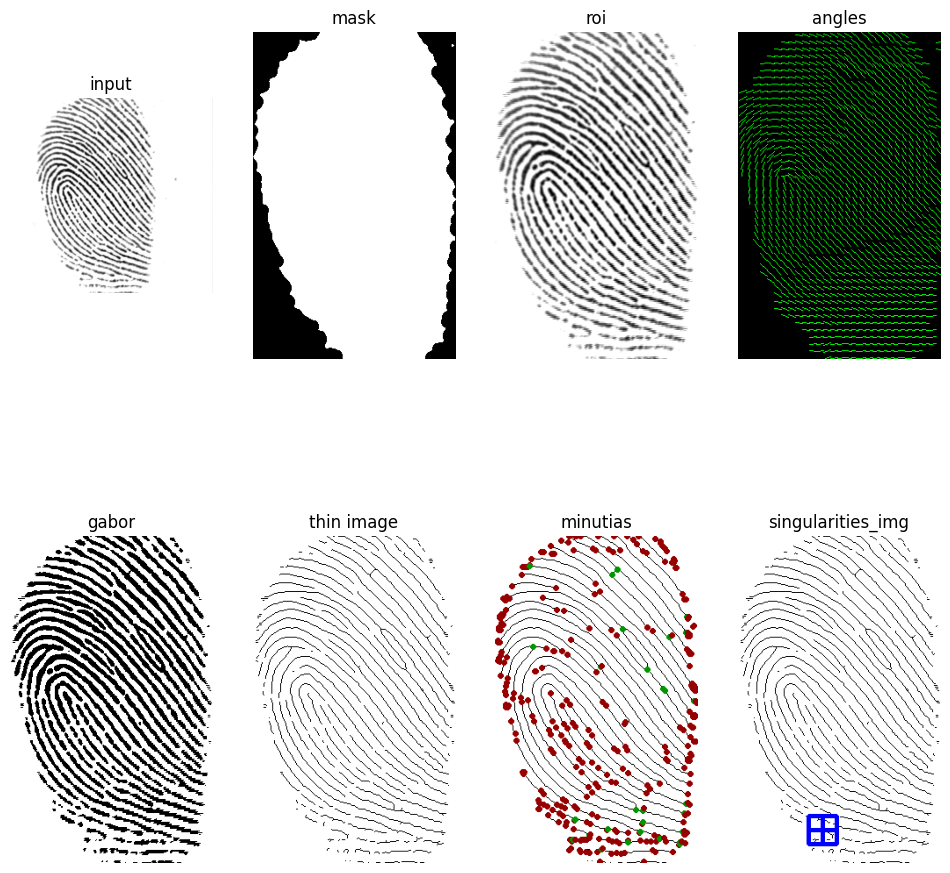

In [ ]:
input_img = cv2.imread(img_paths[5])
input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
mask , roi, norm_img = process_img(img_paths[5])
angles = calc_angles(roi,8,True)
vis = visualize_angles(roi, mask, angles, 8)

freq = ridge_freq(
        norm_img,
        mask,
        angles,
        block_size = 16,
        kernel_size=5,
        minLength=5,
        maxLength=15,
)
gabor_img = gabor_filter(norm_img, angles, freq)
thin_image = skeletonize(gabor_img)
minutias = calculate_minutiaes(thin_image)
singularities_img = calculate_singularities(thin_image, angles, 20, 16, mask)

inputs =[input_img, mask, roi, vis, gabor_img,thin_image,minutias, singularities_img]
titles = [
    "input",
    "mask",
    "roi",
    "angles",
    "gabor",
    "thin image",
    "minutias",
    "singularities_img"
]
display_images(inputs, titles, 2, 4)